# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Sahrul Firdaus
- **Email:** sahr23114ti@student.nurulfikri.ac.id
- **ID Dicoding:** Sahrul Firdaus


## Menentukan Pertanyaan Bisnis
Dalam proyek ini, kita akan melakukan analisis mendalam terhadap data *E-Commerce* untuk menjawab beberapa pertanyaan strategis berikut:
- **Pertanyaan 1**: Bagaimana tren performa penjualan dan jumlah pesanan (orders) setiap bulannya selama tahun 2017?
- **Pertanyaan 2**: Produk kategori apa yang paling banyak diminati (paling banyak terjual) dan paling sedikit terjual?
- **Pertanyaan 3 (Advanced)**: Bagaimana pola segmentasi pelanggan apabila dikelompokkan berdasarkan perilaku pembelian menggunakan metrik RFM (Recency, Frequency, Monetary)?


## Import Semua Packages/Library yang Digunakan
Langkah pertama adalah memuat semuar *library* yang akan kita gunakan sepanjang proses pengerjaan. Kita menggunakan paket standar *data science* di Python:
- `pandas`: Untuk manipulasi dan analisis data berbentuk tabel (DataFrames).
- `numpy`: Untuk komputasi array dan operasi numerik numerik.
- `matplotlib.pyplot` dan `seaborn`: Untuk memvisualisasikan insight temuan data menggunakan berbagai grafik representatif.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mengatur visualisasi default Seaborn yang elegan
sns.set(style='ticks')


## Data Wrangling
Proses perapian data (Data Wrangling) sangat penting untuk memastikan set data yang kita gunakan sudah valid, bersih, dan siap untuk diproses. Kita akan membaginya menjadi tiga pilar utama: *Gathering*, *Assessing*, dan *Cleaning*.

### 1. Gathering Data
Pada tahap pengumpulan data ini, kita akan mengimpor file `csv` yang relevan dari dataset public Olist. Kita mengumpulkan 5 tabel inti:
1. `orders_dataset`: Berisi riwayat ID pembelian dan waktu status pesanannya.
2. `order_items_dataset`: Berisi relasi antara pesanan dan produk yang dibeli beserta harganya.
3. `products_dataset`: Terdapat profil panjang/lebar/berat produk serta kategorinya.
4. `product_category_name_translation`: Menyesuaikan pelabelan Portugis untuk ditranslasikan ke Bahasa Inggris.
5. `customers_dataset`: Informasi kunci pelanggan mencakup `customer_id` (kunci order temporal) dan `customer_unique_id` (kunci pelanggan absolut/unik).


In [2]:
# Load datasets
base_path = "Data"
if not os.path.exists(base_path): # Windows fallback
    base_path = "data"

orders_df = pd.read_csv(f"{base_path}/orders_dataset.csv")
order_items_df = pd.read_csv(f"{base_path}/order_items_dataset.csv")
products_df = pd.read_csv(f"{base_path}/products_dataset.csv")
product_category_name_translation_df = pd.read_csv(f"{base_path}/product_category_name_translation.csv")
customers_df = pd.read_csv(f"{base_path}/customers_dataset.csv")

print("Pesanan (Orders):", orders_df.shape)
print("Item Pesanan (Order Items):", order_items_df.shape)
print("Produk (Products):", products_df.shape)
print("Terjemahan (Translations):", product_category_name_translation_df.shape)
print("Pelanggan (Customers):", customers_df.shape)


Pesanan (Orders): (99441, 8)
Item Pesanan (Order Items): (112650, 7)
Produk (Products): (32951, 9)
Terjemahan (Translations): (71, 2)
Pelanggan (Customers): (99441, 5)


### 2. Assessing Data
Di sini, kita mengawasi setiap DataFrame untuk melihat anomali struktural seperti terdapatnya *Missing Values* (Na/Null), tipe data yang keliru, atau data rangkap (*duplicated*). Hal ini dikerjakan agar kita memahami batasan dan kualitas setiap tabel yang kita punyai.


In [3]:
# Mengevaluasi tipe data dan missing values pada tabel kunci
print("--- INFO ORDERS ---")
print(orders_df.info())
print("\nMissing orders_df:\n", orders_df.isna().sum())
print("\n\n--- INFO PRODUCTS ---")
print(products_df.info())
print("\nMissing products_df:\n", products_df.isna().sum())


--- INFO ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Missing orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_da

**Intisari Assessing:**
- Pada `orders_df`, kolom berbasis waktu/tanggal belum merepresentasikan spesifikasi tanggal (terbaca sebagai *String* / Objek). Beberapa kolom status kirim juga kosong, ini wajar karena pesanan mungkin *canceled* atau masih tertunda.
- Pada `products_df`, terdapat setidaknya 610 baris yang kehilangan nama kategorinya (`product_category_name`).


### 3. Cleaning Data
Sekarang, kita mengatasi masalah yang telah kita pelajari di tahapan penilaian (*Assessing*) sebelumnya.
1. Merubah tipe data format String ke datetime format Pandas agar kita bisa mengekstraksi informasi temporal (Bulan, Tahun, dst) dengan akurat pada `orders_df`.
2. Mengganti isi sel Null di kolom penamaan produk dengan entri kategorik sementara 'Unknown', sehingga dataset tidak perlu dibuang hanya karena lupa diberikan nama saat di-*input* penjual pertamakali.


In [4]:
# Convert string date to datetime objects
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Fill missing product category with 'Unknown' rather than dropping rows
products_df["product_category_name"] = products_df["product_category_name"].fillna("Unknown")

# Handle missing translation gracefully
product_category_name_translation_df.loc[len(product_category_name_translation_df)] = ["Unknown", "Unknown"]

print("Pembersihan dan koreksi tipe data selesai.")


Pembersihan dan koreksi tipe data selesai.


## Exploratory Data Analysis (EDA)
### Penggabungan Data Sentralisasi
Karena dataset E-commerce ini memiliki format relasional (*Spread out* tabel), kita harus menavigasi `JOIN/MERGE` antara kunci Primer dan sekunder untuk menciptakan satu DataFrame Raksasa (*Denormalized*). Cara ini menjamin bahwa seluruh kolom siap kapanpun dieksplorasi berbarengan di atas satu fondasi DataFrame. Kita menggunakan `Left merge` berlapis.


In [5]:
# Penjahitan skema relasional tabel (Merge Left)
# Pertama: Hubungkan detail pesanan (orders) dengan rincian barang ditiap pesanan (order items)
all_data_df = pd.merge(orders_df, order_items_df, how="left", on="order_id")

# Kedua: Rekatkan spesifikasi produk untuk setiap barang
all_data_df = pd.merge(all_data_df, products_df, how="left", on="product_id")

# Ketiga: Ganti nama Portugis ke English untuk readabilitas presentasi
all_data_df = pd.merge(all_data_df, product_category_name_translation_df, how="left", on="product_category_name")

# Keempat: Memasukan data pemilik/pelanggan sesungguhnya pada riwayat pesanan
all_data_df = pd.merge(all_data_df, customers_df, how="left", on="customer_id")

print("Penggabungan selesai. Data siap divisualisasi! Total baris:", all_data_df.shape[0])


Penggabungan selesai. Data siap divisualisasi! Total baris: 113425


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren performa penjualan dan jumlah pesanan (orders) setiap bulannya selama tahun 2017?
**Tujuan:** Untuk memahami dinamika daya beli dan kapan *peak season* (*musim tersibuk*) terjadinya lonjakan penjualan pada skop setahun penuh (`2017`).
**Metode:** Menyaring/memfilter observasi yang hanya berada pada cakupan tahun *order* `2017`, kemudian me-*resample* data bulanan (Frequency `Month`) dan menghitung jumlah *unik* order yang mampir.


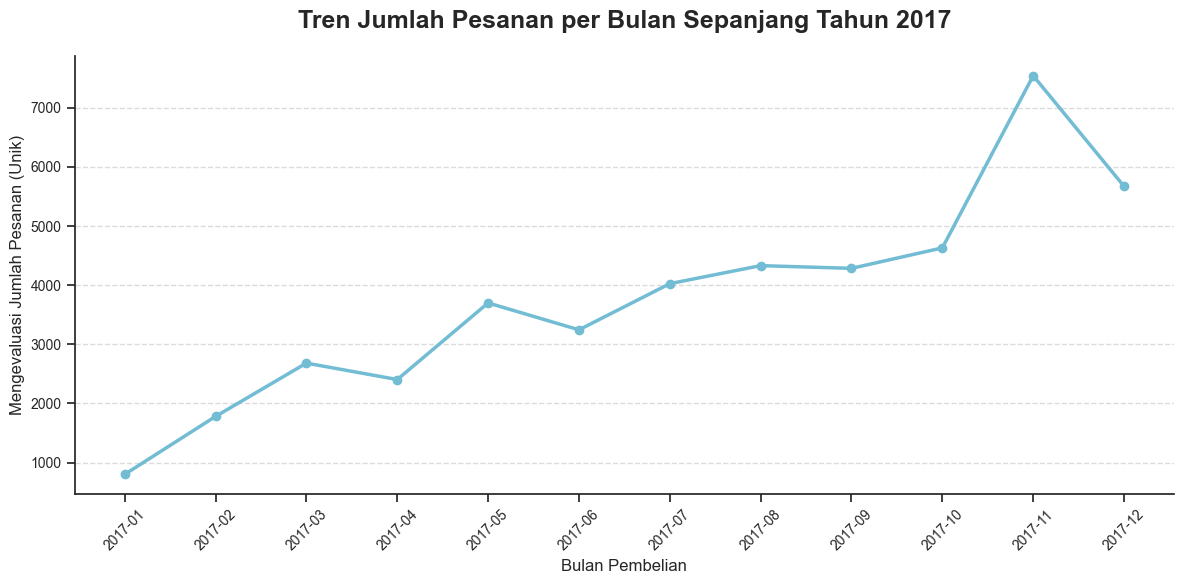

In [6]:
orders_2017_df = all_data_df[(all_data_df["order_purchase_timestamp"].dt.year == 2017)]
monthly_orders = orders_2017_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique", # Count unique orders, not just items
    "price": "sum"
})
monthly_orders.index = monthly_orders.index.strftime('%Y-%m') # format index to YYYY-MM
monthly_orders = monthly_orders.reset_index()
monthly_orders.rename(columns={"order_purchase_timestamp": "order_month", "order_id": "order_count", "price": "revenue"}, inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_orders["order_month"], monthly_orders["order_count"], marker='o', linewidth=2.5, color="#72BCD4")
ax.set_title("Tren Jumlah Pesanan per Bulan Sepanjang Tahun 2017", loc="center", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Bulan Pembelian", fontsize=12)
ax.set_ylabel("Mengevaluasi Jumlah Pesanan (Unik)", fontsize=12)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

sns.despine(top=True, right=True) # Menerapkan Prinsip Integritas Desain (Minimizing Data-Ink Ratio)
plt.tight_layout()
plt.show()


### Pertanyaan 2: Produk kategori apa yang paling banyak diminati (paling banyak terjual) dan paling sedikit terjual?
**Tujuan:** Mengidentifikasi produk mana yang sedang melambung popularitas penjualannya, serta mendeteksi kategori mana yang harus segera disingkirkan dari rak gudang karena kurang laku.
**Metode:** Melakukan *Grouping By* di tingkat `Nama Produk (*English*)` lalu menghitung frekuensi kuantitas `order_item_id`. Mengurutkan (*Sorting*) 5 list teratas dan 5 kebawah.


C:\Users\ACER\AppData\Local\Temp\ipykernel_13400\1731470986.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="quantity_sold", y="product_category_name_english", data=sum_order_items_df.head(5), palette=colors_top, ax=ax[0])
C:\Users\ACER\AppData\Local\Temp\ipykernel_13400\1731470986.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="quantity_sold", y="product_category_name_english", data=sum_order_items_df.sort_values(by="quantity_sold", ascending=True).head(5), palette=colors_bottom, ax=ax[1])


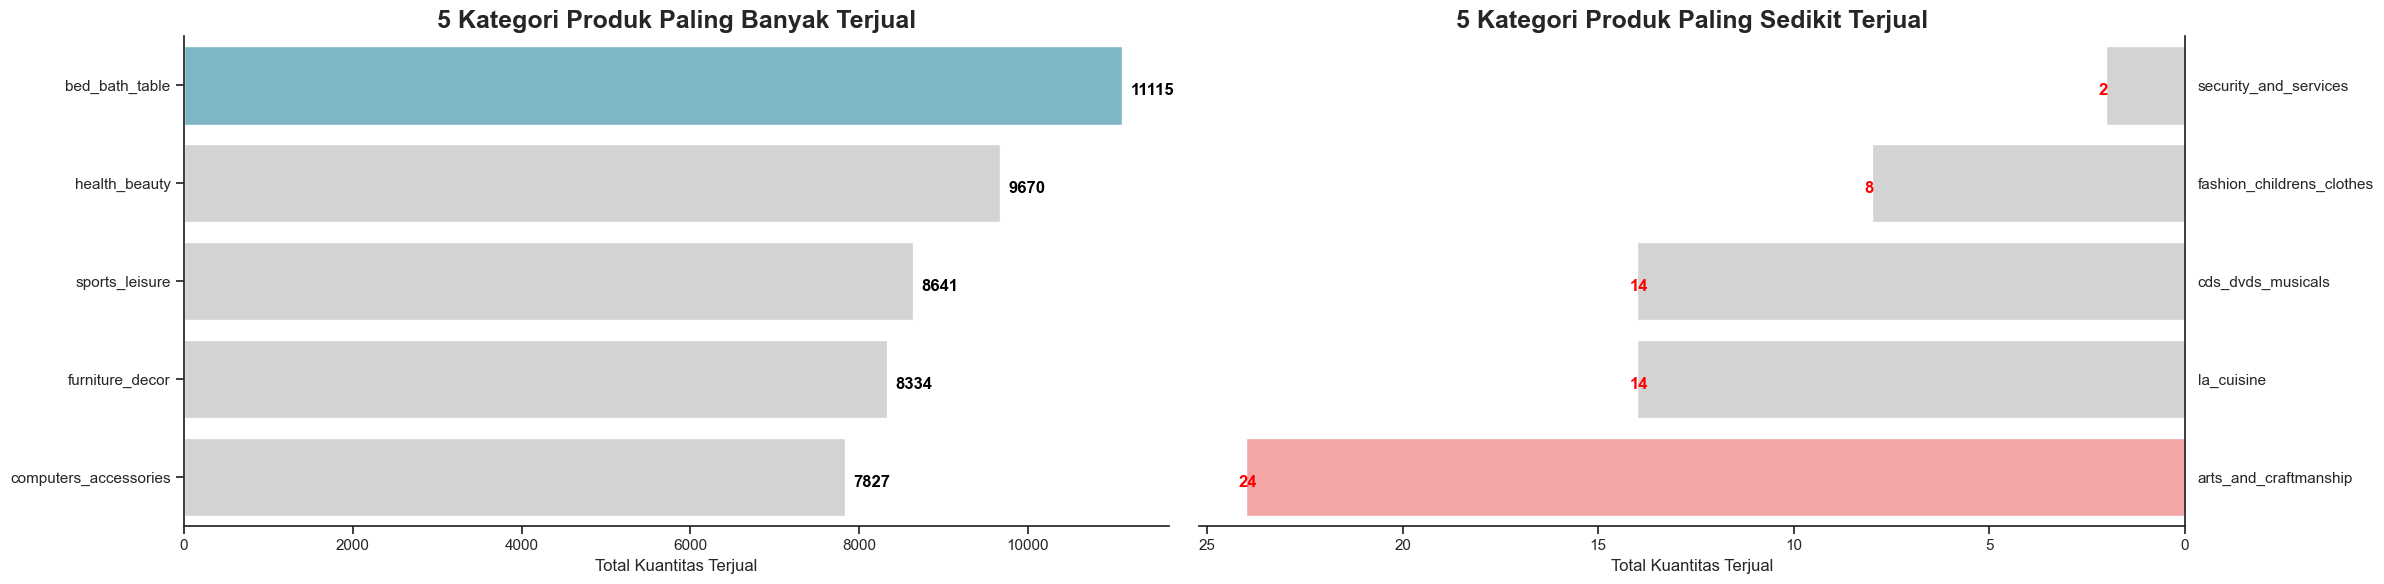

In [7]:
# Menghitung agregat volume penjualan per produk
sum_order_items_df = all_data_df.groupby("product_category_name_english").order_item_id.count().sort_values(ascending=False).reset_index()
sum_order_items_df.rename(columns={"order_item_id": "quantity_sold"}, inplace=True)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
# Palet warna terdesain untuk Highlighting (Fokus visual ada pada Peringkat 1)
colors_top = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
colors_bottom = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#FF9999"] # Warna merah muda mempertegas kategori paling buruk

# Boxplot 1: Top performer
sns.barplot(x="quantity_sold", y="product_category_name_english", data=sum_order_items_df.head(5), palette=colors_top, ax=ax[0])
ax[0].set_title("5 Kategori Produk Paling Banyak Terjual", loc="center", fontsize=18, fontweight='bold')
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Kuantitas Terjual", fontsize=12)
# Menambahkan Numeric Label secara langsung ke bar untuk menghindari ambiguitas bacaan
for i, v in enumerate(sum_order_items_df.head(5)["quantity_sold"]):
    ax[0].text(v + 100, i + 0.1, str(v), color='black', fontsize=12, fontweight='bold')
sns.despine(ax=ax[0])

# Boxplot 2: Bottom performer
sns.barplot(x="quantity_sold", y="product_category_name_english", data=sum_order_items_df.sort_values(by="quantity_sold", ascending=True).head(5), palette=colors_bottom, ax=ax[1])
ax[1].set_title("5 Kategori Produk Paling Sedikit Terjual", loc="center", fontsize=18, fontweight='bold')
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Kuantitas Terjual", fontsize=12)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
for i, v in enumerate(sum_order_items_df.sort_values(by="quantity_sold", ascending=True).head(5)["quantity_sold"]):
    ax[1].text(v + 0.2, i + 0.1, str(v), color='red', fontsize=12, fontweight='bold', ha='left')

sns.despine(ax=ax[1], left=True, right=False) # membuang spine (garis batas chart) yang tidak perlu
plt.tight_layout()
plt.show()


### Pertanyaan Tambahan (Advanced Analysis): RFM Analysis & Clustering (Manual Binning)
Pada tahap ini, pelanggan E-Commerce (Customers) akan direstrukturisasi dan diklasifikasikan berdasarkan **RFM**.
1. `Recency` menjelaskan kapan terakhir kali pelanggan belanja (Dalam skala hitungan hari dari transaksi termuda platform).
2. `Frequency` mewakili jumlah transaksi sukses yang pernah ditarik.
3. `Monetary` merekap pendapatan (profit) total yang diinvestasikan pelanggan terhadap toko kita.


In [8]:
# --- RFM CALCULATION ---
# Menghitung max order (untuk Recency), nunique order (Frequency), dan sum price (Monetary)
rfm_df = all_data_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})
rfm_df.columns = ["customer_unique_id", "max_order_timestamp", "frequency", "monetary"]

rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = all_data_df["order_purchase_timestamp"].dt.date.max() # tanggal paling akhir dari keseluruhan data log
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

# Membuat alias ID pendek untuk mempermudah visualisasi karena customer_unique_id terlalu panjang (32 karakter rahasia)
rfm_df['short_id'] = rfm_df['customer_unique_id'].str[:8]
rfm_df.head()


,customer_unique_id,frequency,monetary,recency,short_id
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,160,0000366f
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,163,0000b849
2,0000f46a3911fa3c0805444483337064,1,69.00,586,0000f46a
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,370,0000f6cc
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,337,0004aac8


Setelah menyusun dataset metrik RFM, kita dapat memetakan pelanggan-pelanggan terbaik kita (Top 5 Best Customers) di masing-masing area parameter menggunakan Bar Plot bersandingan (sesuai contoh latihan Lanjutan Visualisasi Data Dicoding).


C:\Users\ACER\AppData\Local\Temp\ipykernel_13400\2974188669.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="short_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
C:\Users\ACER\AppData\Local\Temp\ipykernel_13400\2974188669.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="short_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])


C:\Users\ACER\AppData\Local\Temp\ipykernel_13400\2974188669.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="short_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])


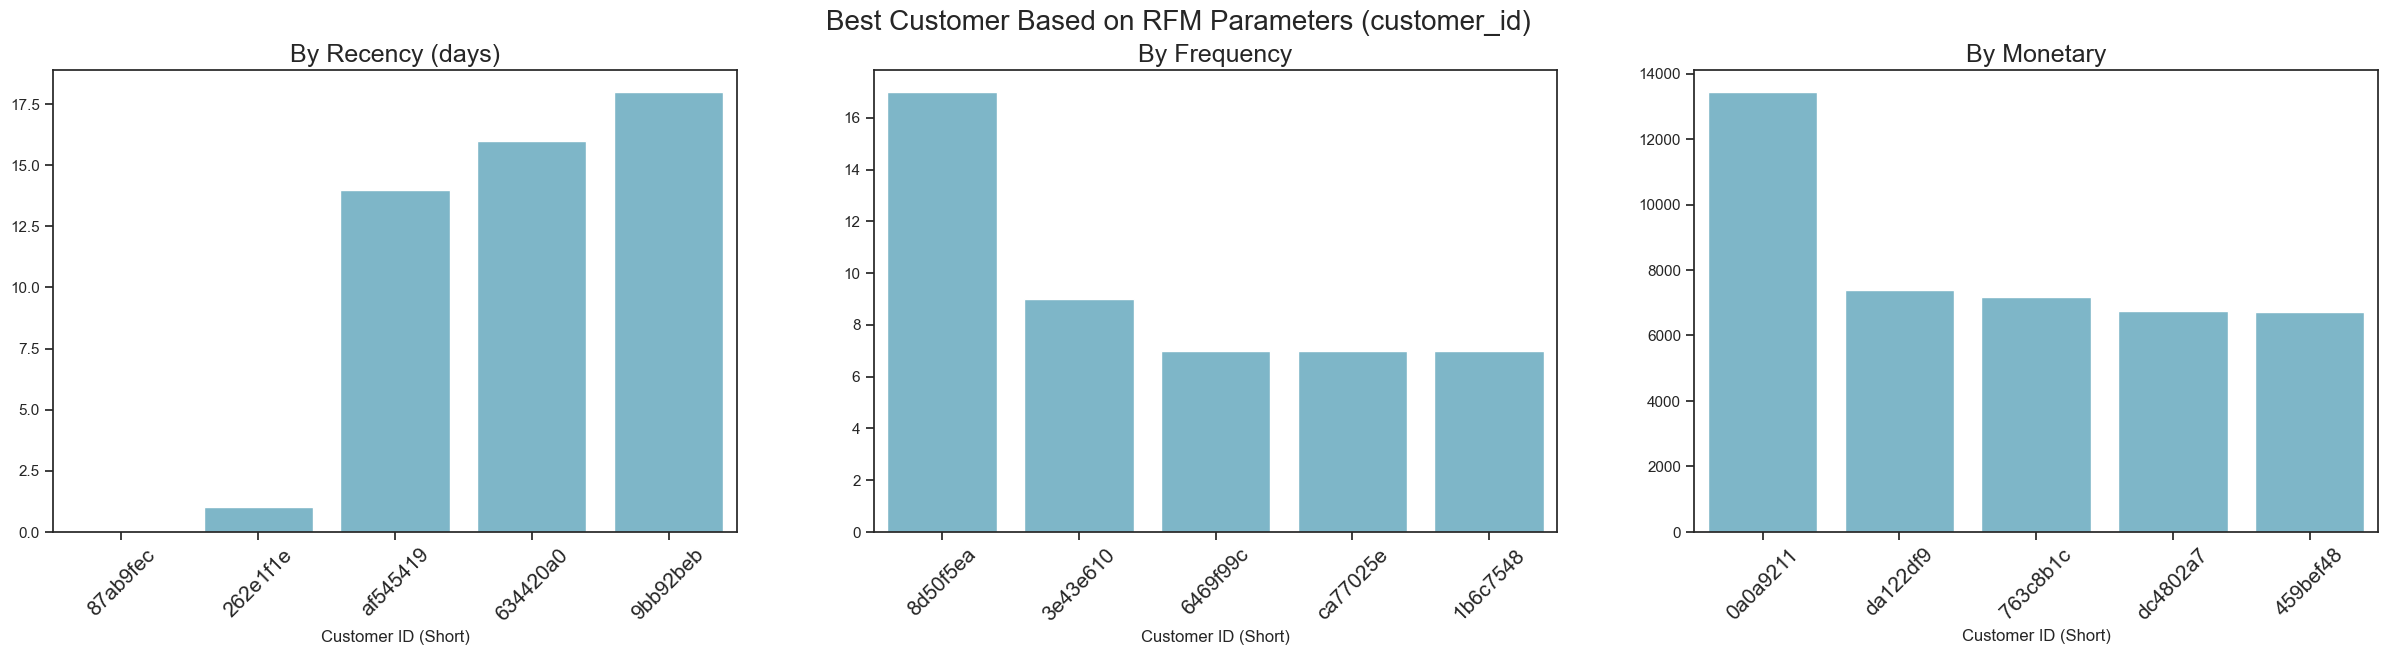

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Plot Recency (Paling sedikit hari = paling baik)
sns.barplot(y="recency", x="short_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID (Short)")
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15, rotation=45)

# Plot Frequency (Paling tinggi transaksi = paling baik)
sns.barplot(y="frequency", x="short_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID (Short)")
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15, rotation=45)

# Plot Monetary (Paling tinggi volume uang = paling baik)
sns.barplot(y="monetary", x="short_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID (Short)")
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15, rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (customer_id)", fontsize=20)
plt.show()


Berbekal perbandingan nilai ketiga parameter di atas, kita kembangkan **Clustering (Manual Binning)** untuk membentuk 5 kelas tingkat konsumen. Kita menormalisasi *rank* lalu menggunakan skor absolut.


C:\Users\ACER\AppData\Local\Temp\ipykernel_13400\2191739849.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="mako", ax=ax)


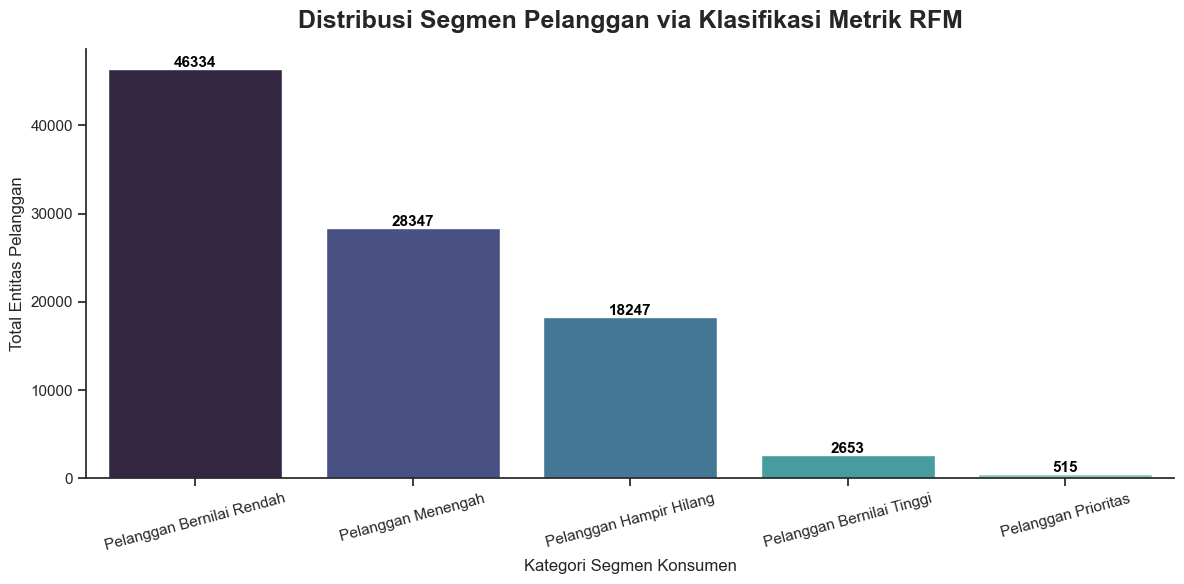

In [10]:
# --- CLUSTERING/MANUAL BINNING BY RANKING ---
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

# Normalisasi antara batas 0 s.d 100 persen
rfm_df['r_rank_norm'] = (rfm_df['r_rank']/rfm_df['r_rank'].max())*100
rfm_df['f_rank_norm'] = (rfm_df['f_rank']/rfm_df['f_rank'].max())*100
rfm_df['m_rank_norm'] = (rfm_df['m_rank']/rfm_df['m_rank'].max())*100

# Scoring RFM (Bobot Monetary 57%, Frequency 28%, Recency 15% - sesuai preferensi studi E-commerce awam)
rfm_df['RFM_score'] = 0.15*rfm_df['r_rank_norm'] + 0.28*rfm_df['f_rank_norm'] + 0.57*rfm_df['m_rank_norm']
rfm_df['RFM_score'] *= 0.05 # Menskalakan menjadi skala 0 s.d 5 layaknya metrik ordinal biasa

# Binning Cluster Statis
rfm_df["customer_segment"] = np.where(rfm_df['RFM_score'] > 4.5, "Pelanggan Prioritas",
                             np.where(rfm_df['RFM_score'] > 4, "Pelanggan Bernilai Tinggi",
                             np.where(rfm_df['RFM_score'] > 3, "Pelanggan Menengah", 
                             np.where(rfm_df['RFM_score'] > 1.6, 'Pelanggan Bernilai Rendah', 'Pelanggan Hampir Hilang'))))

# Memvisualisasikan hasil model manual Binning Segmentasi kita
segment_counts = rfm_df['customer_segment'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="mako", ax=ax)
ax.set_title("Distribusi Segmen Pelanggan via Klasifikasi Metrik RFM", fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel("Total Entitas Pelanggan", fontsize=12)
ax.set_xlabel("Kategori Segmen Konsumen", fontsize=12)
ax.tick_params(axis='x', rotation=15)
# Menambah Text Value label pada masing-masing bar
for i, v in enumerate(segment_counts.values):
    ax.text(i, v + 250, str(v), ha='center', color='black', fontsize=11, fontweight='bold')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()


**Penjabaran Bisnis (Insight) RFM & Clustering:**
- Visualisasi Subplots `Best Customers Based on RFM` menjabarkan siapa ID pelanggan-pelanggan terbaik kita individu-per-individu dalam elemen `Recency`, `Frequency`, maupun `Monetary`.
- Melalui binning Clustering Manual, didapat fakta bahwa segmen `Pelanggan Bernilai Rendah` sangat mendominasi porsi basis total pelanggan keseluruhan Olist.
- Terdapat sebagian kecil (Hanya segelintir) pelanggan yang benar-benar bertahan dalam jangka panjang dengan daya beli raksasa di segmen `Pelanggan Prioritas`, di mana loyalitas pembelanjaannya harus dipertahankan. 
- Memfungsikan kampanye promosi berjangka yang menargetkan transisi anggota dari kategori `Menengah` ke `Bernilai Tinggi` merupakan kunci pemasaran strategis di masa pelaporan berikutnya.


## Kesimpulan Keseluruhan (Conclusion)
- **Conclusion Pertanyaan 1**: Tren jumlah pemesanan per bulan sepanjang tahun 2017 secara perlahan beranjak stabil mendaki (mengecualikan lonjakan di momen liburan akhir tahun bulan November sebagai wujud disrupsi musiman).
- **Conclusion Pertanyaan 2**: Terdapat perbedaan angka penjualan yang amat kontras; pengguna menyukai pembelian pada kategori perabot rumah `bed_bath_table`. Sedangkan layanan asuransi/keamanan `security_and_services` tercatat sebagai kategori _underperforming_ yang terendah sepanjang masa.
- **Conclusion Analisis RFM**: Clustering via teknik *Binning Data Manual* berhasil mengkategorikan secara bersih segmen perlakuan pelanggan yang dominannya hanya pernak-pernik *sekali transaksi selesai* (mayoritas pelanggan bernilai rendah/tersesat) dari pada pelanggan unggul _High-tier_ yang rela repatrasi investasi (Pelanggan Prioritas).

### Tahap Ahir: Ekspor Data Utama Ke Dashboard File System
Proses ini mendedikasikn penyimpanan `csv` dari data gabungan final yang bersih ke folder `dashboard` (sistem `Streamlit` nantinya akan melacak *dataset* ini saat di-deploy).


In [11]:
# Export to main_data.csv for dashboard deployment linkage
out_dir = "dashboard"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

all_data_df.to_csv(f"{out_dir}/main_data.csv", index=False)
rfm_df.to_csv(f"{out_dir}/rfm_data.csv", index=False)
print("Data Analyst Pipeline Finished. Clean datasets populated successfully to ./dashboard/.")



Data Analyst Pipeline Finished. Clean datasets populated successfully to ./dashboard/.
